# 营销渠道效果分析 - 描述型分析与数据可视化

## 📊 项目概述

本Notebook对三大营销渠道的投放数据进行全面的描述型分析和可视化，
通过转化漏斗和ROI指标评估各渠道价值，为营销决策提供数据支撑。

### 数据说明
- **日期范围**：2025年1月
- **渠道数量**：3个渠道（渠道1、渠道2、渠道3）
- **数据量**：25条记录

### 分析维度
1. 各渠道核心指标对比分析
2. 转化漏斗分析
3. ROI投资回报率分析
4. 可视化图表展示

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 设置颜色方案
COLORS = {
    '渠道 1': '#00d4ff',
    '渠道 2': '#00ff88',
    '渠道3': '#ffd700',
    'primary': '#1a1a2e',
    'secondary': '#16213e',
    'accent': '#0f3460',
    'highlight': '#e94560'
}

print("✅ 库导入成功！")

✅ 库导入成功！


---

## 1. 数据加载与概览

In [2]:
# 加载数据
df = pd.read_csv('assets/data/1.描述型分析与数据可视化.csv', encoding='utf-8-sig')

# 查看数据基本信息
print("="*60)
print("数据概览")
print("="*60)
print(f"\n数据形状: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"\n列名: {list(df.columns)}")
print(f"\n数据类型:")
print(df.dtypes)

数据概览

数据形状: 25 行 × 9 列

列名: ['日期', '渠道', '销售收入', '花费', '点击量', '展现量', '点击采购次数', '跳转账号密码页次数', '交易笔数']

数据类型:
日期           object
渠道           object
销售收入          int64
花费            int64
点击量           int64
展现量           int64
点击采购次数        int64
跳转账号密码页次数     int64
交易笔数          int64
dtype: object


In [3]:
# 数据预览
print("\n" + "="*60)
print("数据预览（前10行）")
print("="*60)
df.head(10)


数据预览（前10行）


,日期,渠道,销售收入,花费,点击量,展现量,点击采购次数,跳转账号密码页次数,交易笔数
0,2025/1/1,渠道 1,1800000,9000,25000,350000,1200,600,500
1,2025/1/2,渠道 1,1654321,8564,16476,314765,1174,564,514
2,2025/1/3,渠道 1,1754321,8564,17476,314765,1174,564,514
3,2025/1/4,渠道 1,1654321,8564,16476,314765,1174,564,514
4,2025/1/5,渠道 1,1543211,7243,16236,252365,843,436,387
5,2025/1/6,渠道 1,1543211,7243,16236,252365,843,436,387
6,2025/1/7,渠道 1,1543211,7243,16236,252365,843,436,387
7,2025/1/8,渠道 1,1543211,7243,16236,252365,843,436,387
8,2025/1/1,渠道 2,1200000,6000,18000,250000,900,450,350
9,2025/1/2,渠道 2,1400000,7500,17556,265678,876,468,419


In [4]:
# 数据质量检查
print("\n" + "="*60)
print("数据质量检查")
print("="*60)

# 缺失值
missing = df.isnull().sum()
print(f"缺失值统计:")
print(missing if missing.sum() > 0 else "✅ 无缺失值")

# 重复值
duplicates = df.duplicated().sum()
print(f"\n重复行数: {duplicates}")

# 渠道分布
print(f"\n渠道分布:")
print(df['渠道'].value_counts())


数据质量检查
缺失值统计:
✅ 无缺失值

重复行数: 1

渠道分布:
渠道
渠道3     9
渠道 1    8
渠道 2    8
Name: count, dtype: int64


---

## 2. 描述性统计分析

In [5]:
# 数值型变量描述统计
print("="*60)
print("数值型变量描述统计")
print("="*60)
df.describe().round(2)

数值型变量描述统计


,销售收入,花费,点击量,展现量,点击采购次数,跳转账号密码页次数,交易笔数
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,1284099.04,7075.04,16316.88,259539.92,884.48,442.32,386.60
std,303635.04,905.45,2559.23,36190.78,149.14,70.63,65.85
min,804321.00,5832.00,12832.00,210365.00,706.00,340.00,290.00
25%,1043211.00,6323.00,14632.00,232365.00,792.00,392.00,342.00
50%,1300000.00,7000.00,16236.00,252365.00,843.00,436.00,387.00
75%,1543211.00,7500.00,17476.00,280000.00,925.00,468.00,406.00
max,1800000.00,9000.00,25000.00,350000.00,1200.00,600.00,514.00


In [6]:
# 各渠道汇总统计
print("\n" + "="*60)
print("各渠道核心指标汇总")
print("="*60)

channel_summary = df.groupby('渠道').agg({
    '销售收入': 'sum',
    '花费': 'sum',
    '点击量': 'sum',
    '展现量': 'sum',
    '点击采购次数': 'sum',
    '跳转账号密码页次数': 'sum',
    '交易笔数': 'sum'
}).round(2)

# 计算衍生指标
channel_summary['ROI'] = (channel_summary['销售收入'] / channel_summary['花费']).round(2)
channel_summary['转化率(点击-采购)'] = (channel_summary['点击采购次数'] / channel_summary['点击量'] * 100).round(2)
channel_summary['成交率(采购-交易)'] = (channel_summary['交易笔数'] / channel_summary['点击采购次数'] * 100).round(2)
channel_summary['整体转化率'] = (channel_summary['交易笔数'] / channel_summary['展现量'] * 100).round(4)

channel_summary


各渠道核心指标汇总


,销售收入,花费,点击量,展现量,点击采购次数,跳转账号密码页次数,交易笔数,ROI,转化率(点击-采购),成交率(采购-交易),整体转化率
渠道,,,,,,,,,,,
渠道 1,13035807,63664,140372,2303755,8094,4036,3590,204.76,5.77,44.35,0.1558
渠道 2,8806174,51530,125284,1942962,6548,3271,2822,170.89,5.23,43.10,0.1452
渠道3,10260495,61682,142266,2241781,7470,3751,3253,166.35,5.25,43.55,0.1451


---

## 3. 综合可视化分析

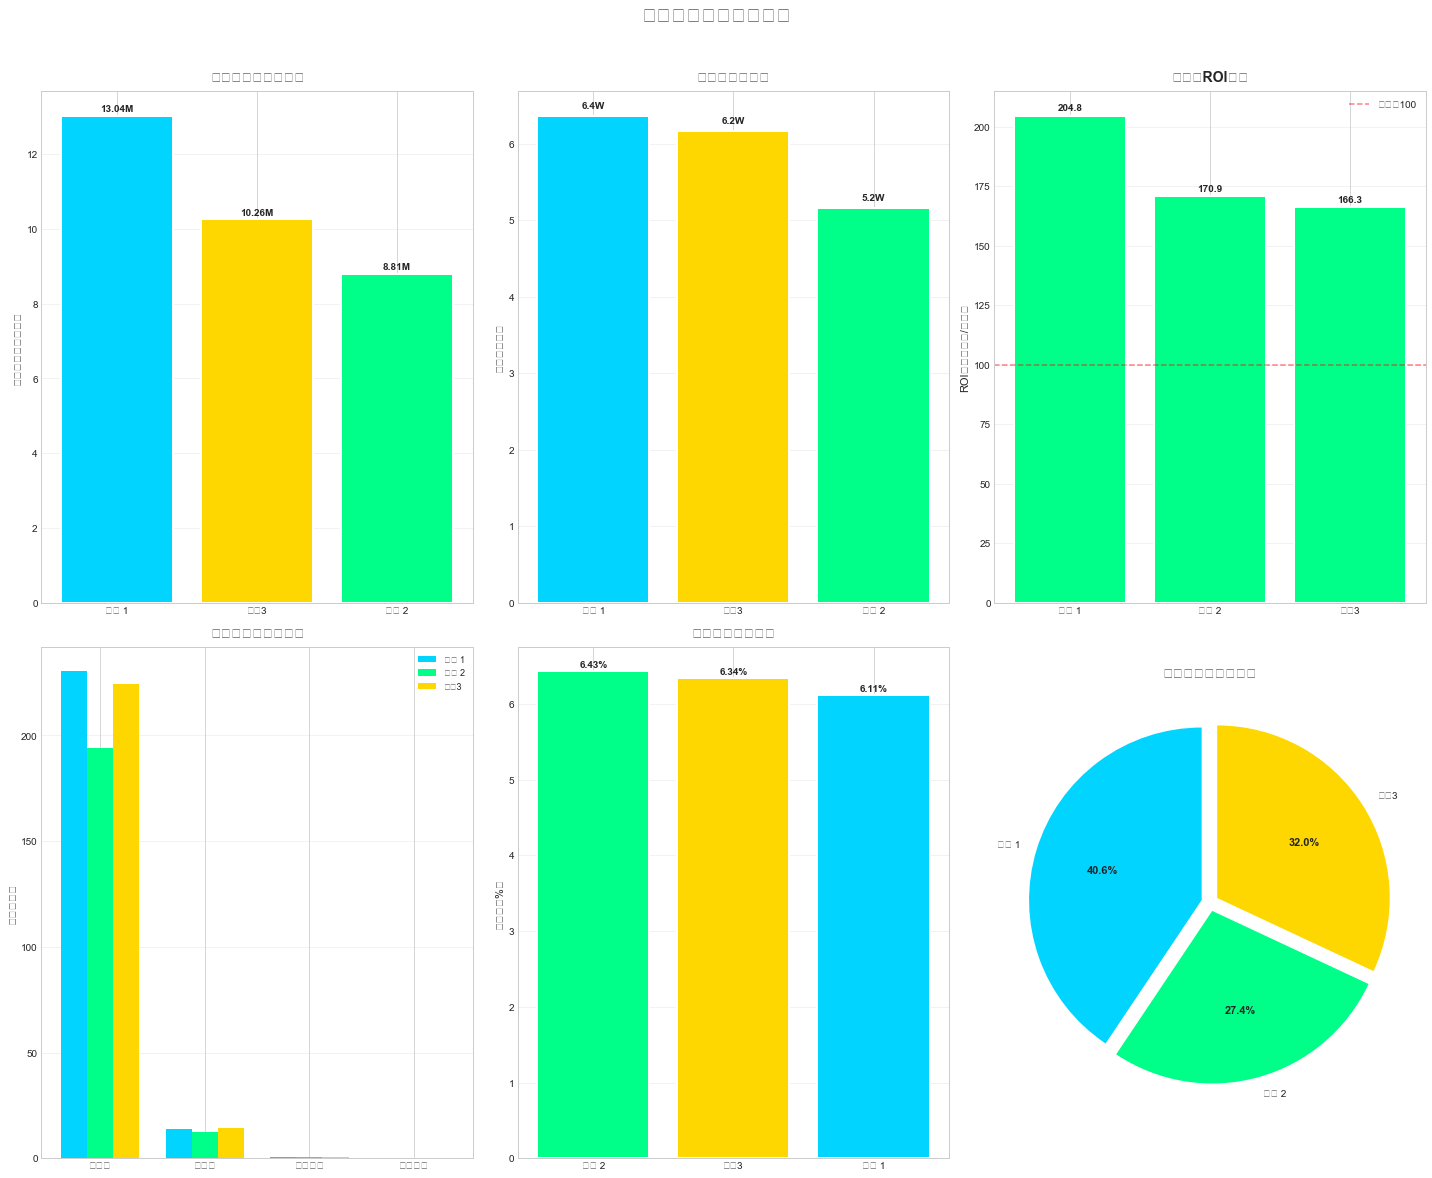


✅ 综合分析图表已保存


In [7]:
# 创建综合分析图表
fig = plt.figure(figsize=(20, 16))

# 1. 各渠道销售收入对比
ax1 = fig.add_subplot(2, 3, 1)
sales_by_channel = df.groupby('渠道')['销售收入'].sum().sort_values(ascending=False)
colors = [COLORS.get(c, '#888888') for c in sales_by_channel.index]
bars = ax1.bar(sales_by_channel.index, sales_by_channel.values / 1e6, color=colors, edgecolor='white', linewidth=2)
ax1.set_title('各渠道销售收入对比', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('销售收入（百万元）', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, sales_by_channel.values / 1e6):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}M', ha='center', fontsize=10, fontweight='bold')

# 2. 各渠道花费对比
ax2 = fig.add_subplot(2, 3, 2)
cost_by_channel = df.groupby('渠道')['花费'].sum().sort_values(ascending=False)
bars = ax2.bar(cost_by_channel.index, cost_by_channel.values / 1e4, color=colors, edgecolor='white', linewidth=2)
ax2.set_title('各渠道花费对比', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('花费（万元）', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, cost_by_channel.values / 1e4):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.1f}W', ha='center', fontsize=10, fontweight='bold')

# 3. ROI对比
ax3 = fig.add_subplot(2, 3, 3)
roi_data = channel_summary['ROI'].sort_values(ascending=False)
colors_roi = ['#00ff88' if v > 100 else '#ffd700' if v > 50 else '#ff4757' for v in roi_data.values]
bars = ax3.bar(roi_data.index, roi_data.values, color=colors_roi, edgecolor='white', linewidth=2)
ax3.set_title('各渠道ROI对比', fontsize=14, fontweight='bold', pad=10)
ax3.set_ylabel('ROI（销售收入/花费）', fontsize=11)
ax3.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='基准线100')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, roi_data.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# 4. 转化漏斗对比
ax4 = fig.add_subplot(2, 3, 4)
funnel_data = channel_summary[['展现量', '点击量', '点击采购次数', '交易笔数']].loc[['渠道 1', '渠道 2', '渠道3']]
x = np.arange(len(funnel_data.columns))
width = 0.25
for i, (channel, row) in enumerate(funnel_data.iterrows()):
    ax4.bar(x + i*width, row.values / 1e4, width, label=channel, color=list(COLORS.values())[i])
ax4.set_title('各渠道转化漏斗对比', fontsize=14, fontweight='bold', pad=10)
ax4.set_xticks(x + width)
ax4.set_xticklabels(['展现量', '点击量', '点击采购', '交易笔数'], fontsize=10)
ax4.set_ylabel('数量（万）', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# 5. 点击率对比
ax5 = fig.add_subplot(2, 3, 5)
df['点击率'] = df['点击量'] / df['展现量'] * 100
ctr_by_channel = df.groupby('渠道')['点击率'].mean().sort_values(ascending=False)
bars = ax5.bar(ctr_by_channel.index, ctr_by_channel.values, color=[COLORS.get(c, '#888') for c in ctr_by_channel.index], edgecolor='white', linewidth=2)
ax5.set_title('各渠道平均点击率', fontsize=14, fontweight='bold', pad=10)
ax5.set_ylabel('点击率（%）', fontsize=11)
ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, ctr_by_channel.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

# 6. 渠道占比饼图
ax6 = fig.add_subplot(2, 3, 6)
sales_pct = df.groupby('渠道')['销售收入'].sum()
colors_pie = [COLORS.get(c, '#888') for c in sales_pct.index]
wedges, texts, autotexts = ax6.pie(sales_pct, labels=sales_pct.index, autopct='%1.1f%%', 
                                 colors=colors_pie, startangle=90, explode=[0.05]*3)
ax6.set_title('各渠道销售收入占比', fontsize=14, fontweight='bold', pad=10)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.suptitle('营销渠道效果综合分析', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/images/channel_analysis_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 综合分析图表已保存")

---

## 4. 转化漏斗深度分析

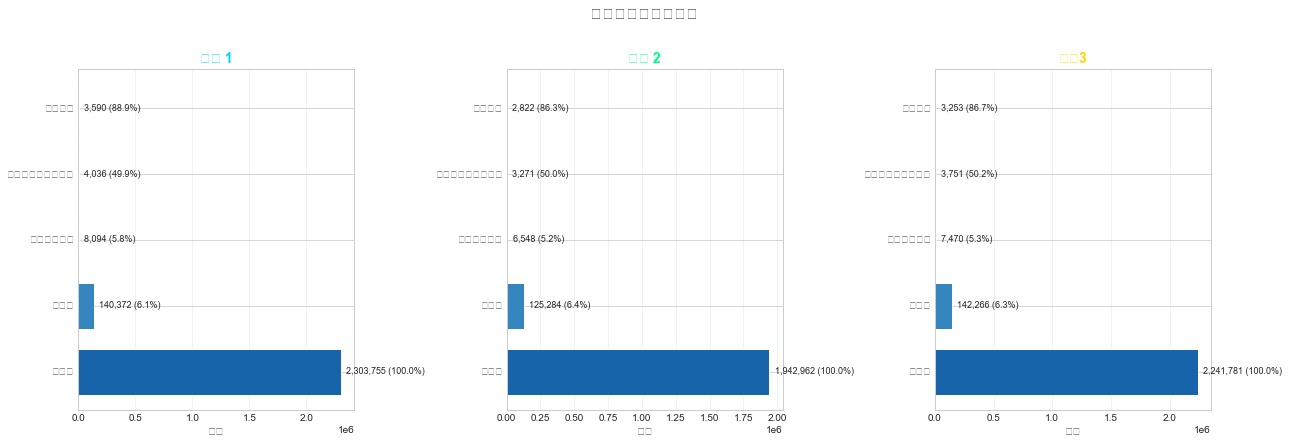


✅ 转化漏斗分析图已保存


In [8]:
# 转化漏斗可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

channels = ['渠道 1', '渠道 2', '渠道3']

for idx, channel in enumerate(channels):
    ax = axes[idx]
    data = channel_summary.loc[channel]
    
    # 漏斗数据
    stages = ['展现量', '点击量', '点击采购次数', '跳转账号密码页次数', '交易笔数']
    values = [data['展现量'], data['点击量'], data['点击采购次数'], 
              data['跳转账号密码页次数'], data['交易笔数']]
    
    # 计算转化率
    conversion_rates = [100]
    for i in range(1, len(values)):
        rate = values[i] / values[i-1] * 100
        conversion_rates.append(rate)
    
    # 绘制漏斗图
    y_positions = np.arange(len(stages))
    colors_funnel = plt.cm.Blues(np.linspace(0.8, 0.3, len(stages)))
    
    bars = ax.barh(y_positions, values, color=colors_funnel, edgecolor='white', height=0.7)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(stages)
    ax.set_xlabel('数量', fontsize=11)
    ax.set_title(f'{channel}', fontsize=14, fontweight='bold', color=COLORS.get(channel, '#333'))
    ax.grid(axis='x', alpha=0.3)
    
    # 添加数值标签
    for bar, val, rate in zip(bars, values, conversion_rates):
        ax.text(val + max(values)*0.02, bar.get_y() + bar.get_height()/2, 
                f'{val:,.0f} ({rate:.1f}%)', va='center', fontsize=9)

plt.suptitle('各渠道转化漏斗分析', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/images/funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 转化漏斗分析图已保存")

---

## 5. 渠道效果雷达图

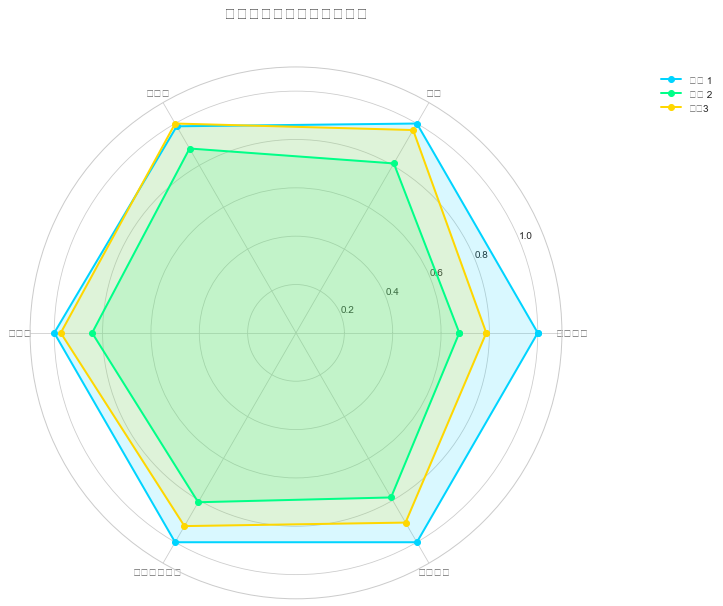


✅ 雷达图已保存


In [9]:
# 创建渠道对比雷达图
from math import pi

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 准备雷达图数据（归一化）
metrics = ['销售收入', '花费', '点击量', '展现量', '点击采购次数', '交易笔数']
channels = ['渠道 1', '渠道 2', '渠道3']

# 归一化数据
radar_data = channel_summary[metrics].copy()
for col in metrics:
    max_val = radar_data[col].max()
    if max_val > 0:
        radar_data[col] = radar_data[col] / max_val

# 设置角度
angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

# 绘制雷达图
for i, channel in enumerate(channels):
    values = radar_data.loc[channel].values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=channel, color=list(COLORS.values())[i])
    ax.fill(angles, values, alpha=0.15, color=list(COLORS.values())[i])

# 设置标签
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.title('各渠道核心指标雷达图对比', fontsize=16, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig('assets/images/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 雷达图已保存")

---

## 6. 关键指标汇总表

In [10]:
# 创建详细的汇总表格
print("="*80)
print("营销渠道效果分析汇总表")
print("="*80)

summary_table = channel_summary.copy()
summary_table.columns = ['销售收入', '花费', '点击量', '展现量', '点击采购次数', 
                          '跳转账号页', '交易笔数', 'ROI', '转化率(点击-采购)%', 
                          '成交率(采购-交易)%', '整体转化率%']

# 格式化显示
summary_display = summary_table.copy()
summary_display['销售收入'] = summary_display['销售收入'].apply(lambda x: f'{x:,.0f}')
summary_display['花费'] = summary_display['花费'].apply(lambda x: f'{x:,.0f}')
summary_display['点击量'] = summary_display['点击量'].apply(lambda x: f'{x:,.0f}')
summary_display['展现量'] = summary_display['展现量'].apply(lambda x: f'{x:,.0f}')
summary_display['点击采购次数'] = summary_display['点击采购次数'].apply(lambda x: f'{x:,.0f}')
summary_display['跳转账号页'] = summary_display['跳转账号页'].apply(lambda x: f'{x:,.0f}')
summary_display['交易笔数'] = summary_display['交易笔数'].apply(lambda x: f'{x:,.0f}')

summary_display

营销渠道效果分析汇总表


,销售收入,花费,点击量,展现量,点击采购次数,跳转账号页,交易笔数,ROI,转化率(点击-采购)%,成交率(采购-交易)%,整体转化率%
渠道,,,,,,,,,,,
渠道 1,"13,035,807","63,664","140,372","2,303,755","8,094","4,036","3,590",204.76,5.77,44.35,0.1558
渠道 2,"8,806,174","51,530","125,284","1,942,962","6,548","3,271","2,822",170.89,5.23,43.10,0.1452
渠道3,"10,260,495","61,682","142,266","2,241,781","7,470","3,751","3,253",166.35,5.25,43.55,0.1451


---

## 7. 分析结论与建议

In [11]:
# 生成分析报告
print("="*80)
print("营销渠道效果分析报告")
print("="*80)

# 找出最佳渠道
best_roi_channel = channel_summary['ROI'].idxmax()
best_sales_channel = channel_summary['销售收入'].idxmax()
best_conversion_channel = channel_summary['整体转化率'].idxmax()

# 计算总体数据
total_sales = channel_summary['销售收入'].sum()
total_cost = channel_summary['花费'].sum()
total_roi = total_sales / total_cost

print(f"\n📊 【总体概览】")
print(f"   总销售收入: {total_sales:,.0f} 元")
print(f"   总花费: {total_cost:,.0f} 元")
print(f"   总体ROI: {total_roi:.2f}")

print(f"\n🏆 【各维度最佳渠道】")
print(f"   最高ROI: {best_roi_channel} (ROI={channel_summary.loc[best_roi_channel, 'ROI']:.2f})")
print(f"   最高销售收入: {best_sales_channel} (销售收入={channel_summary.loc[best_sales_channel, '销售收入']:,.0f})")
print(f"   最高整体转化率: {best_conversion_channel} (转化率={channel_summary.loc[best_conversion_channel, '整体转化率']:.4f}%)")

print(f"\n💡 【渠道评价】")
for channel in ['渠道 1', '渠道 2', '渠道3']:
    roi = channel_summary.loc[channel, 'ROI']
    conv = channel_summary.loc[channel, '整体转化率']
    
    if roi > 100 and conv > 0.15:
        rating = "⭐⭐⭐ 优质渠道"
    elif roi > 50:
        rating = "⭐⭐ 良好渠道"
    else:
        rating = "⭐ 需优化"
    
    print(f"   {channel}: {rating}")
    print(f"      - ROI: {roi:.2f}, 整体转化率: {conv:.4f}%")

print(f"\n📝 【优化建议】")
print(f"   1. 建议加大对{best_roi_channel}的投放预算")
print(f"   2. 分析{best_sales_channel}的高收入原因，复制到其他渠道")
print(f"   3. 关注渠道间的转化率差异，针对性优化漏斗各环节")

营销渠道效果分析报告

📊 【总体概览】
   总销售收入: 32,102,476 元
   总花费: 176,876 元
   总体ROI: 181.50

🏆 【各维度最佳渠道】
   最高ROI: 渠道 1 (ROI=204.76)
   最高销售收入: 渠道 1 (销售收入=13,035,807)
   最高整体转化率: 渠道 1 (转化率=0.1558%)

💡 【渠道评价】
   渠道 1: ⭐⭐⭐ 优质渠道
      - ROI: 204.76, 整体转化率: 0.1558%
   渠道 2: ⭐⭐ 良好渠道
      - ROI: 170.89, 整体转化率: 0.1452%
   渠道3: ⭐⭐ 良好渠道
      - ROI: 166.35, 整体转化率: 0.1451%

📝 【优化建议】
   1. 建议加大对渠道 1的投放预算
   2. 分析渠道 1的高收入原因，复制到其他渠道
   3. 关注渠道间的转化率差异，针对性优化漏斗各环节


---

## 📁 生成的文件

本Notebook生成了以下图表文件：
- `channel_analysis_overview.png` - 渠道综合分析图（6宫格）
- `funnel_analysis.png` - 转化漏斗对比图
- `radar_chart.png` - 雷达图对比

## ✅ 分析完成

本Notebook完成了以下分析内容：
1. 数据加载与质量检查
2. 描述性统计分析
3. 各渠道核心指标对比
4. ROI投资回报率分析
5. 转化漏斗深度分析
6. 雷达图综合对比
7. 生成分析报告与建议